<a href="https://colab.research.google.com/github/SatishGollamudi/GenerativeAI/blob/main/AutoEncodersuisngpytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Autoencoders: An Overview**

Autoencoders are a unique class of unsupervised feedforward neural networks that operate without the need for labeled data. It's core purpose is to learn efficient, compressed representations of input data — enabling applications such as dimensionality reduction, synthetic data generation, and anomaly detection.

A standard Autoencoder consists of two complementary neural network components:

**Encoder:** This network takes the raw input and progressively compresses it into a smaller, dense representation known as the latent space or bottleneck. In doing so, it strips away redundant information and retains only the most essential features. The size of this bottleneck layer is a tunable hyperparameter that controls how aggressively the data is compressed.

**Decoder:** Working exclusively from the latent space representation, the decoder attempts to reconstruct the original input as faithfully as possible. Its architecture typically mirrors that of the encoder in reverse. The quality of this reconstruction is evaluated using a loss function that quantifies the reconstruction error — the gap between the original input and the decoded output.

During training, data is repeatedly passed through both components, and the reconstruction error is used to update the network's parameters via backpropagation. Over many iterations, the Autoencoder progressively improves its ability to capture even the most complex and nuanced patterns in the data.



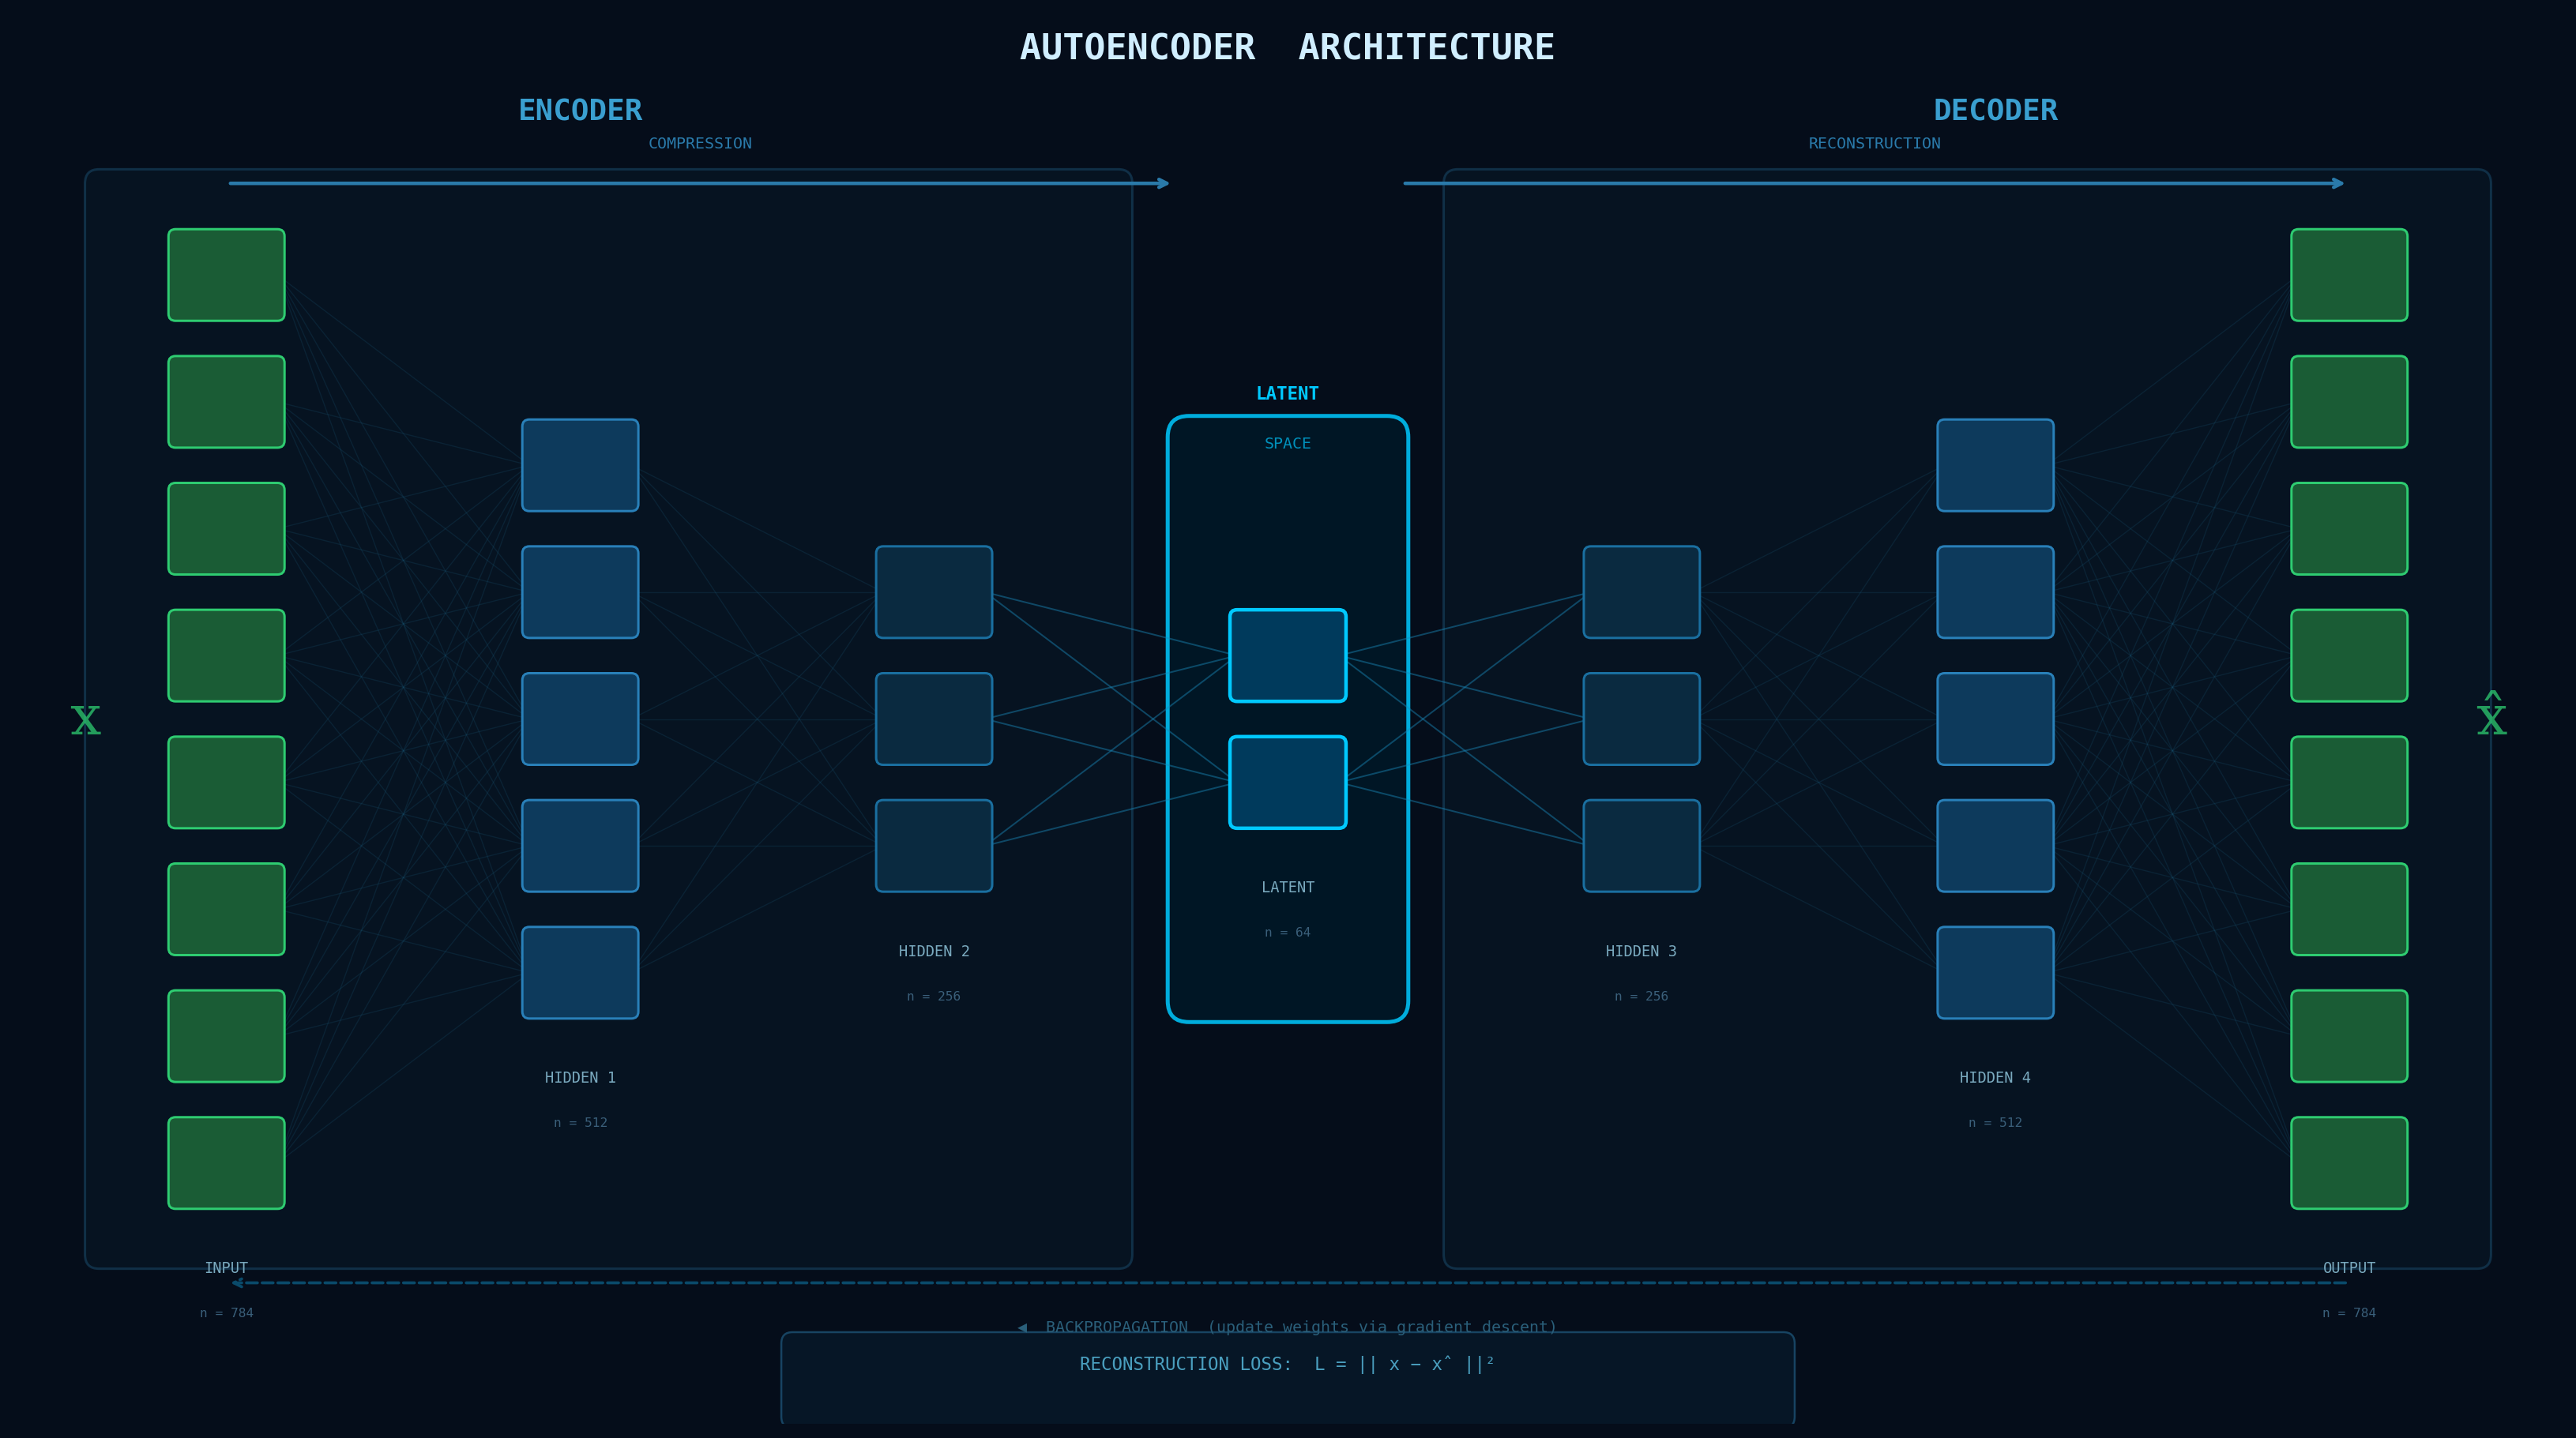

**Autoencoders as a Dimensionality Reduction Tool**

When the input features fed into an Autoencoder have no meaningful relationship with one another, the model struggles to identify a compact representation that preserves the essential structure of the data — inevitably resulting in significant information loss during compression.
This characteristic positions Autoencoders as a viable dimensionality reduction technique. Unlike classical approaches such as ***Principal Component Analysis (PCA)***, which is constrained to linear projections, Autoencoders can leverage non-linear transformations to map data into lower-dimensional spaces — often capturing far more complex patterns in the process.
It is also worth noting that, unlike general-purpose compression formats such as gzip, Autoencoders are not universal compressors. They are task-specific models, trained and optimized to work exclusively on data that closely resembles their training distribution.

Key Hyperparameters to Tune
Several hyperparameters govern the performance of an Autoencoder and can be adjusted during optimization:

**Network depth** — the number of layers in both the Encoder and Decoder
Layer width — the number of neurons at each layer
Loss function — the metric used to measure reconstruction quality (e.g., Mean Squared Error for continuous data or Binary Cross-Entropy for binary outputs)
Latent space size — a smaller bottleneck enforces stronger compression, which also acts as a form of regularization by discouraging the model from memorizing input details


**Flexibility Across Data Types**

**Autoencoders** are highly adaptable and can be architected to handle diverse data formats — whether tabular, time-series, or image data. Depending on the domain, the underlying layer types can be swapped accordingly; for instance, Convolutional layers are commonly employed when working with image data due to their ability to capture spatial hierarchies.

**The Generalization Balance**

A well-optimized Autoencoder must strike a careful balance: it needs to be expressive enough to accurately capture the meaningful structure of the input data, yet constrained enough to avoid simply memorizing it. An overly flexible model risks overfitting — reproducing the training data perfectly while failing to generalize to new, unseen examples. The goal is a model that learns the underlying patterns, not the noise.

**Types of Autoencoders**

*   Undercomplete Autoencoder
*   Sparse Autoencoder
*   Contractive Autoencoder
*   Denoising Autoencoder
*   Convolutional Autoencoder
*   Variational Autoencoder


**Undercomplete Autoencoder**

The Undercomplete Autoencoder represents the most fundamental form of the autoencoder family. Rather than relying on an explicit regularization term, it controls overfitting through a structural constraint — the bottleneck layer is always kept smaller than the original input dimensionality. This architectural choice naturally forces the model to learn only the most meaningful features of the data. Because of this property, Undercomplete Autoencoders are widely used as a dimensionality reduction tool, and they hold a distinct advantage over PCA by being capable of capturing non-linear relationships within the data.

**Sparse Autoencoder**

On the surface, a Sparse Autoencoder shares many similarities with its Undercomplete counterpart — but the two diverge fundamentally in how they approach regularization. A key distinction is that Sparse Autoencoders do not require the bottleneck to be smaller than the input. Instead, compression is achieved indirectly through the loss function itself.

Specifically, the loss function is designed to discourage the simultaneous activation of too many neurons across the hidden layers. This mechanism is known as a ***sparsity penalty*** — and it differs considerably from conventional regularization strategies like L1 or L2, which target the magnitude of the model's weights.

The sparsity penalty, by contrast, targets neuronal activity, pushing the network to develop efficient, selective representations where only a small subset of neurons fire for any given input.

This results in a model that learns distributed yet sparse internal encodings — often producing more interpretable and robust feature representations compared to the Undercomplete approach.

**Contractive Autoencoder**

The core idea here is simple — if two inputs are very similar to each other, their compressed versions should also be very similar. In other words, the model should not produce wildly different compressed outputs for inputs that are only slightly different from one another. To achieve this, the model is trained to keep the changes in its internal activations as small as possible when the input changes slightly. This makes the model more stable and robust to minor variations in the input data.

**Denoising Autoencoder**

In most autoencoders, the goal is to take an input and reconstruct that exact same input at the output. Denoising Autoencoders work differently — the input and output are not the same. Instead, the model is deliberately fed a damaged or noisy version of the data as input, and its job is to produce a clean, corrected version as output. For example, you could feed in a blurry or corrupted image and expect the model to output a clear version of it. To train and evaluate this, you need to have access to the original clean data so the model has something to compare its predictions against.

**Convolutional Autoencoder**

When working with image data, standard feedforward layers are replaced with Convolutional Neural Network layers in both the encoder and decoder. This makes the model much better at understanding images because convolutional layers are specifically designed to pick up on visual patterns like edges, shapes, and textures. Convolutional Autoencoders are also flexible — by changing the loss function or adding penalties, they can be turned into Sparse or Denoising Autoencoders depending on what the task requires.

**Variational Autoencoder (VAE)**

In all the autoencoder types discussed so far, the encoder produces a single fixed value for each dimension in the compressed representation. Variational Autoencoders take a different approach — instead of outputting one fixed value, the encoder produces a probability distribution for each dimension. The decoder then picks a value by sampling from each of these distributions and uses those sampled values to reconstruct the original input. This probabilistic approach makes VAEs especially powerful for generating new, realistic-looking data that did not exist in the original training set.

In [6]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from mpl_toolkits.mplot3d import Axes3D

df = pd.read_csv("/content/sample_data/weatherAUS.csv")
df = df.drop(['Date', 'Location', 'WindDir9am',
             'WindGustDir', 'WindDir3pm'], axis=1)
df = df.dropna(how = 'any')
df.loc[df['RainToday'] == 'No', 'RainToday'] = 0
df.loc[df['RainToday'] == 'Yes', 'RainToday'] = 1
df.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
5939,17.9,35.2,0.0,12.0,12.3,48.0,6.0,20.0,20.0,13.0,1006.3,1004.4,2.0,5.0,26.6,33.4,0,0.0,No
5940,18.4,28.9,0.0,14.8,13.0,37.0,19.0,19.0,30.0,8.0,1012.9,1012.1,1.0,1.0,20.3,27.0,0,0.0,No
5942,19.4,37.6,0.0,10.8,10.6,46.0,30.0,15.0,42.0,22.0,1012.3,1009.2,1.0,6.0,28.7,34.9,0,0.0,No
5943,21.9,38.4,0.0,11.4,12.2,31.0,6.0,6.0,37.0,22.0,1012.7,1009.1,1.0,5.0,29.1,35.6,0,0.0,No
5944,24.2,41.0,0.0,11.2,8.4,35.0,17.0,13.0,19.0,15.0,1010.7,1007.4,1.0,6.0,33.6,37.6,0,0.0,No


In [7]:
X, Y = df.drop('RainTomorrow', axis=1, inplace=False), df[['RainTomorrow']]
# Normalizing Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Converting to PyTorch tensor
X_tensor = torch.FloatTensor(X_scaled)

# Converting string labels to numerical labels
label_encoder = LabelEncoder()
Y_numerical = label_encoder.fit_transform(Y.values.ravel())

In [8]:
# Defining Autoencoder model
class Autoencoder(nn.Module):
   def __init__(self, input_size, encoding_dim):
       super(Autoencoder, self).__init__()
       self.encoder = nn.Sequential(
           nn.Linear(input_size, 16),
           nn.ReLU(),
           nn.Linear(16, encoding_dim),
           nn.ReLU()
       )
       self.decoder = nn.Sequential(
           nn.Linear(encoding_dim, 16),
           nn.ReLU(),
           nn.Linear(16, input_size),
           nn.Sigmoid()
       )

   def forward(self, x):
       x = self.encoder(x)
       x = self.decoder(x)
       return x

In [9]:
# Setting random seed for reproducibility
torch.manual_seed(42)

input_size = X.shape[1]  # Number of input features
encoding_dim = 3  # Desired number of output dimensions
model = Autoencoder(input_size, encoding_dim)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

# Training the autoencoder
num_epochs = 20
for epoch in range(num_epochs):
   # Forward pass
   outputs = model(X_tensor)
   loss = criterion(outputs, X_tensor)

   # Backward pass and optimization
   optimizer.zero_grad()
   loss.backward()
   optimizer.step()

   # Loss for each epoch
   print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

# Encoding the data using the trained autoencoder
encoded_data = model.encoder(X_tensor).detach().numpy()

Epoch [1/20], Loss: 1.2521
Epoch [2/20], Loss: 1.2494
Epoch [3/20], Loss: 1.2467
Epoch [4/20], Loss: 1.2439
Epoch [5/20], Loss: 1.2411
Epoch [6/20], Loss: 1.2382
Epoch [7/20], Loss: 1.2353
Epoch [8/20], Loss: 1.2323
Epoch [9/20], Loss: 1.2292
Epoch [10/20], Loss: 1.2259
Epoch [11/20], Loss: 1.2226
Epoch [12/20], Loss: 1.2191
Epoch [13/20], Loss: 1.2155
Epoch [14/20], Loss: 1.2118
Epoch [15/20], Loss: 1.2079
Epoch [16/20], Loss: 1.2038
Epoch [17/20], Loss: 1.1995
Epoch [18/20], Loss: 1.1950
Epoch [19/20], Loss: 1.1903
Epoch [20/20], Loss: 1.1853


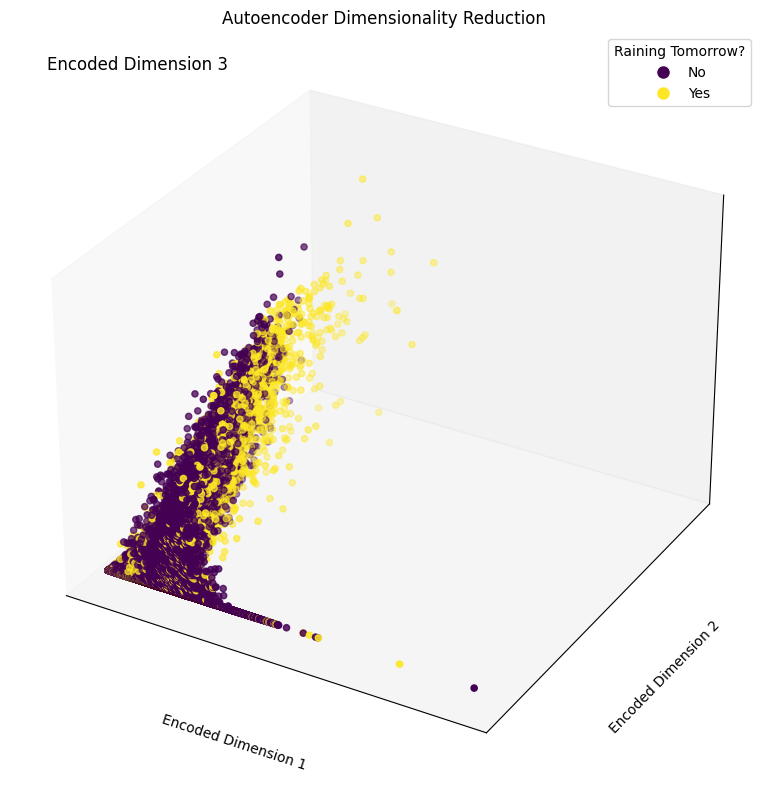

In [10]:
# Plotting the encoded data in 3D space
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(encoded_data[:, 0], encoded_data[:, 1],
                    encoded_data[:, 2], c=Y_numerical, cmap='viridis')

# Mapping numerical labels back to original string labels for the legend
labels = label_encoder.inverse_transform(np.unique(Y_numerical))
legend_labels = {num: label for num, label in zip(np.unique(Y_numerical),
                                                 labels)}

# Creating a custom legend with original string labels
handles = [plt.Line2D([0], [0], marker='o', color='w',
                    markerfacecolor=scatter.to_rgba(num),
                    markersize=10,
                    label=legend_labels[num]) for num in np.unique(Y_numerical)]
ax.legend(handles=handles, title="Raining Tomorrow?")

# Adjusting the layout to provide more space for labels
ax.xaxis.labelpad = 20
ax.yaxis.labelpad = 20

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

# Manually adding z-axis label for better visibility
ax.text2D(0.05, 0.95, 'Encoded Dimension 3', transform=ax.transAxes,
         fontsize=12, color='black')

ax.set_xlabel('Encoded Dimension 1')
ax.set_ylabel('Encoded Dimension 2')
ax.set_title('Autoencoder Dimensionality Reduction')

plt.tight_layout()

plt.savefig('Rain_Prediction_Autoencoder.png')

plt.show()